### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

Primi 10 paesi per consumo totale:
                country  total_litres_of_pure_alcohol
15              Belarus                          14.4
98            Lithuania                          12.9
3               Andorra                          12.4
68              Grenada                          11.9
61               France                          11.8
45       Czech Republic                          11.8
141  Russian Federation                          11.5
99           Luxembourg                          11.4
155            Slovakia                          11.4
81              Ireland                          11.4
Media consumo birra: 106.16062176165804
Media consumo vino: 49.45077720207254
Media consumo distillati: 80.99481865284974
Paese con alcohol_index massimo:
country             Andorra
alcohol_index    231.666667
Name: 3, dtype: object
Paesi che consumano più di 100 birre all'anno:
               country  beer_servings
3              Andorra            245
4             

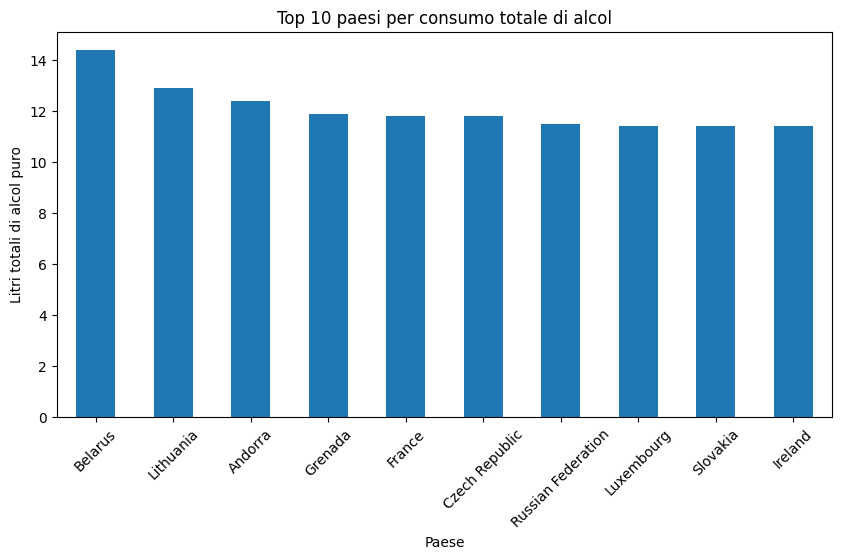

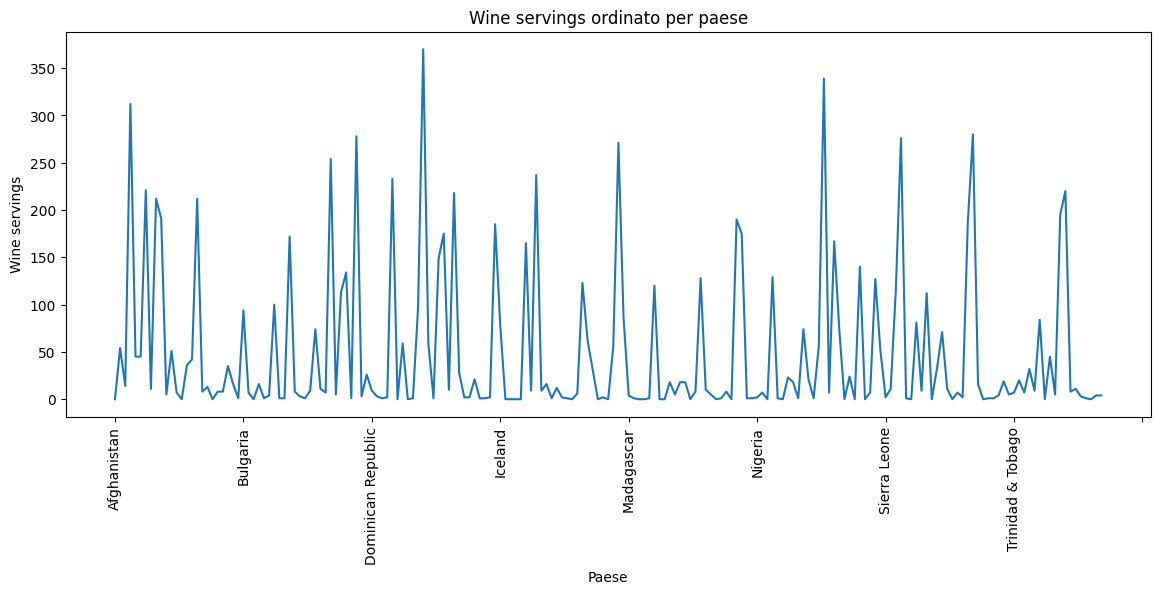

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

top_10_total = df.sort_values("total_litres_of_pure_alcohol", ascending=False).head(10)
print("Primi 10 paesi per consumo totale:")
print(top_10_total[["country", "total_litres_of_pure_alcohol"]])

media_birra = df["beer_servings"].mean()
media_vino = df["wine_servings"].mean()
media_distillati = df["spirit_servings"].mean()

print("Media consumo birra:", media_birra)
print("Media consumo vino:", media_vino)
print("Media consumo distillati:", media_distillati)

df["alcohol_index"] = (df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]) / 3

paese_max_index = df.loc[df["alcohol_index"].idxmax()]
print("Paese con alcohol_index massimo:")
print(paese_max_index[["country", "alcohol_index"]])

paesi_piu_100_birre = df[df["beer_servings"] > 100]
print("Paesi che consumano più di 100 birre all'anno:")
print(paesi_piu_100_birre[["country", "beer_servings"]])

top_10_total.plot(x="country",y="total_litres_of_pure_alcohol",kind="bar",legend=False,figsize=(10, 5))

plt.title("Top 10 paesi per consumo totale di alcol")
plt.xlabel("Paese")
plt.ylabel("Litri totali di alcol puro")
plt.xticks(rotation=45)
plt.show()

df_wine_sorted = df.sort_values("country")

df_wine_sorted.plot(x="country",y="wine_servings",kind="line",figsize=(14, 5),legend=False)

plt.title("Wine servings ordinato per paese")
plt.xlabel("Paese")
plt.ylabel("Wine servings")
plt.xticks(rotation=90)
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

c:\Users\ameer\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analisi per paese:
                          stipendio_medio  numero_offerte  stipendio_minimo  \
job_country                                                                   
Belarus                     400000.000000             543          400000.0   
Russia                      292500.000000            3743          250000.0   
Bahamas                     201511.619048              69          173500.0   
Dominican Republic          157500.000000             478          157500.0   
Northern Mariana Islands    155485.500000               4          155485.5   
...                                   ...             ...               ...   
Tanzania                              NaN              50               NaN   
Togo                                  NaN              17               NaN   
Trinidad and Tobago                   NaN              58               NaN   
Venezuela                             NaN              69               NaN   
Yemen                            

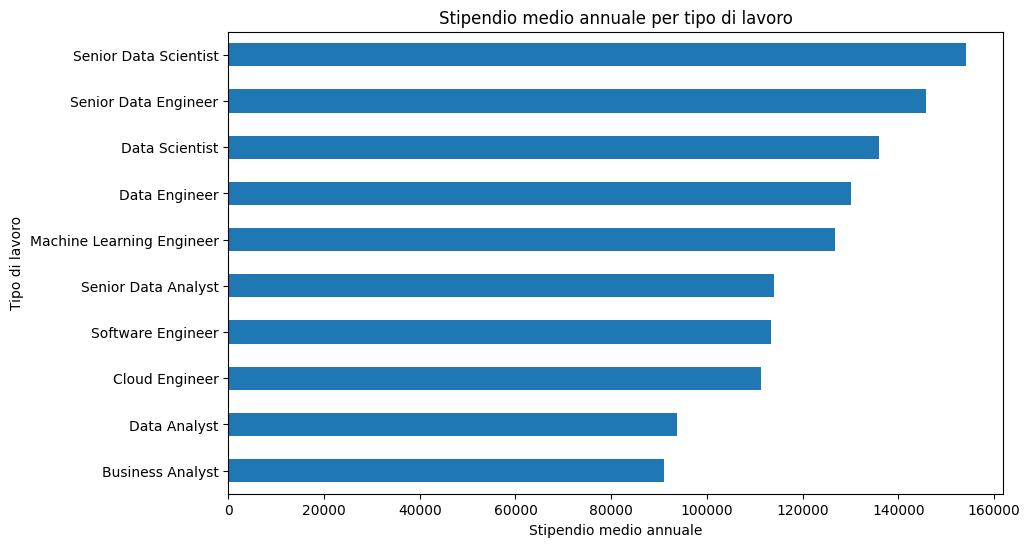

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

analisi_paese = df.groupby("job_country").agg(
    stipendio_medio=("salary_year_avg", "mean"),
    numero_offerte=("job_title_short", "count"),
    stipendio_minimo=("salary_year_avg", "min"),
    stipendio_massimo=("salary_year_avg", "max")
).sort_values("stipendio_medio", ascending=False)

print("Analisi per paese:")
print(analisi_paese)

stipendio_per_lavoro = df.groupby("job_title_short")["salary_year_avg"].mean().sort_values(ascending=False)

print("Stipendio medio per job_title_short:")
print(stipendio_per_lavoro)

stipendio_per_lavoro.sort_values().plot(kind="barh",figsize=(10, 6))

plt.title("Stipendio medio annuale per tipo di lavoro")
plt.xlabel("Stipendio medio annuale")
plt.ylabel("Tipo di lavoro")
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

Analisi per giorno:
      conto_medio  numero_osservazioni  conto_minimo  conto_massimo
day                                                                
Sun     21.410000                   76          7.25          48.17
Sat     20.441379                   87          3.07          50.81
Thur    17.682742                   62          7.51          43.11
Fri     17.151579                   19          5.75          40.17
Giorno con conto medio più alto:
Sun
Prime righe con conto_per_persona:
   total_bill   tip     sex smoker  day    time  size  conto_per_persona
0       16.99  1.01  Female     No  Sun  Dinner     2           8.495000
1       10.34  1.66    Male     No  Sun  Dinner     3           3.446667
2       21.01  3.50    Male     No  Sun  Dinner     3           7.003333
3       23.68  3.31    Male     No  Sun  Dinner     2          11.840000
4       24.59  3.61  Female     No  Sun  Dinner     4           6.147500


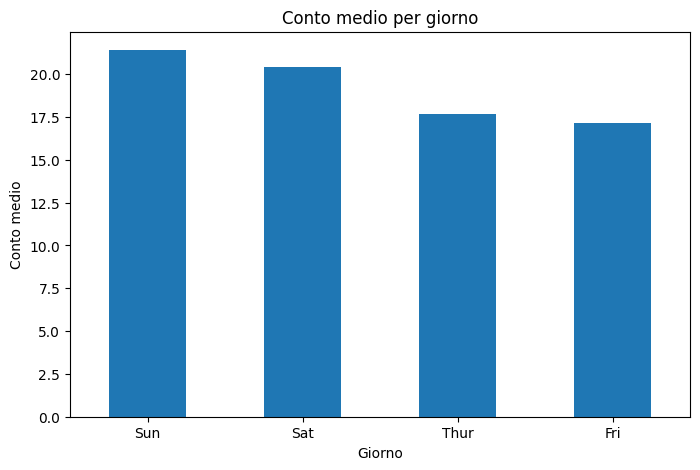

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

analisi_giorno = df.groupby("day").agg(
    conto_medio=("total_bill", "mean"),
    numero_osservazioni=("total_bill", "count"),
    conto_minimo=("total_bill", "min"),
    conto_massimo=("total_bill", "max")
).sort_values("conto_medio", ascending=False)

print("Analisi per giorno:")
print(analisi_giorno)

df["conto_per_persona"] = df["total_bill"] / df["size"]

giorno_conto_medio_piu_alto = analisi_giorno["conto_medio"].idxmax()

print("Giorno con conto medio più alto:")
print(giorno_conto_medio_piu_alto)

print("Prime righe con conto_per_persona:")
print(df.head())

analisi_giorno["conto_medio"].plot(kind="bar",figsize=(8, 5))

plt.title("Conto medio per giorno")
plt.xlabel("Giorno")
plt.ylabel("Conto medio")
plt.xticks(rotation=0)
plt.show()